# iQuHack 2026 - Quantum Entanglement Distillation Game

In this game, you design quantum circuits to distill noisy Bell pairs and claim edges in a network.

**Game Flow**: Register -> Select Starting Node -> Design Circuits -> Claim Edges -> Score Points

In [22]:
from client import GameClient
from visualization import GraphTool
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import json
from pathlib import Path

## Session Management

Save/load your session to avoid re-registering.

In [23]:
SESSION_FILE = Path("session.json")

def save_session(client):
    if client.api_token:
        with open(SESSION_FILE, "w") as f:
            json.dump({"api_token": client.api_token, "player_id": client.player_id, "name": client.name}, f)
        print(f"Session saved.")

def load_session():
    if not SESSION_FILE.exists():
        return None
    with open(SESSION_FILE) as f:
        data = json.load(f)
    client = GameClient(api_token=data.get("api_token"))
    client.player_id = data.get("player_id")
    client.name = data.get("name")
    status = client.get_status()
    if status:
        print(f"Resumed: {client.player_id} | Score: {status.get('score', 0)} | Budget: {status.get('budget', 0)}")
        return client
    return None

In [24]:
# Try to resume existing session
client = load_session()

if not client:
    print("No saved session. Register below.")

Resumed: 453 | Score: 0 | Budget: 76


## Step 1: Register

Skip this if you resumed a session above.

In [25]:
if client and client.api_token:
    print(f"Already registered as {client.player_id}")
else:
    client = GameClient()
    
    # CHANGE THESE to your unique values
    PLAYER_ID = "453"
    PLAYER_NAME = "Shane"
    
    result = client.register(PLAYER_ID, PLAYER_NAME, location="remote")
    
    if result.get("ok"):
        print(f"Registered! Token: {client.api_token[:20]}...")
        candidates = result["data"].get("starting_candidates", [])
        print(f"\nStarting candidates ({len(candidates)}):")
        for c in candidates:
            print(f"  - {c['node_id']}: {c['utility_qubits']} qubits, +{c['bonus_bell_pairs']} bonus")
        save_session(client)
    else:
        print(f"Failed: {result.get('error', {}).get('message')}")

Already registered as 453


## Step 2: Select Starting Node

In [26]:
status = client.get_status()

if status.get('starting_node'):
    print(f"Starting node: {status['starting_node']}")
    print(f"Budget: {status['budget']} | Score: {status['score']}")
else:
    print("Select a starting node from the candidates shown above.")
    # Uncomment and modify:
    result = client.select_starting_node("Algiers, Algeria")
    print(result)

Starting node: Algiers, Algeria
Budget: 76 | Score: 0


## Step 3: Explore the Network

In [27]:
client.print_status()

Player: 453 (Shane)
Score: 0 | Budget: 76 bell pairs
Active: Yes
Starting node: Algiers, Algeria
Owned: 1 nodes, 0 edges


Claimable edges: 4
  - ['Algiers, Algeria', 'Valencia, Spain']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Tunis, Tunisia']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Barcelona, Spain']: threshold=0.90, difficulty=3
  ... and 1 more


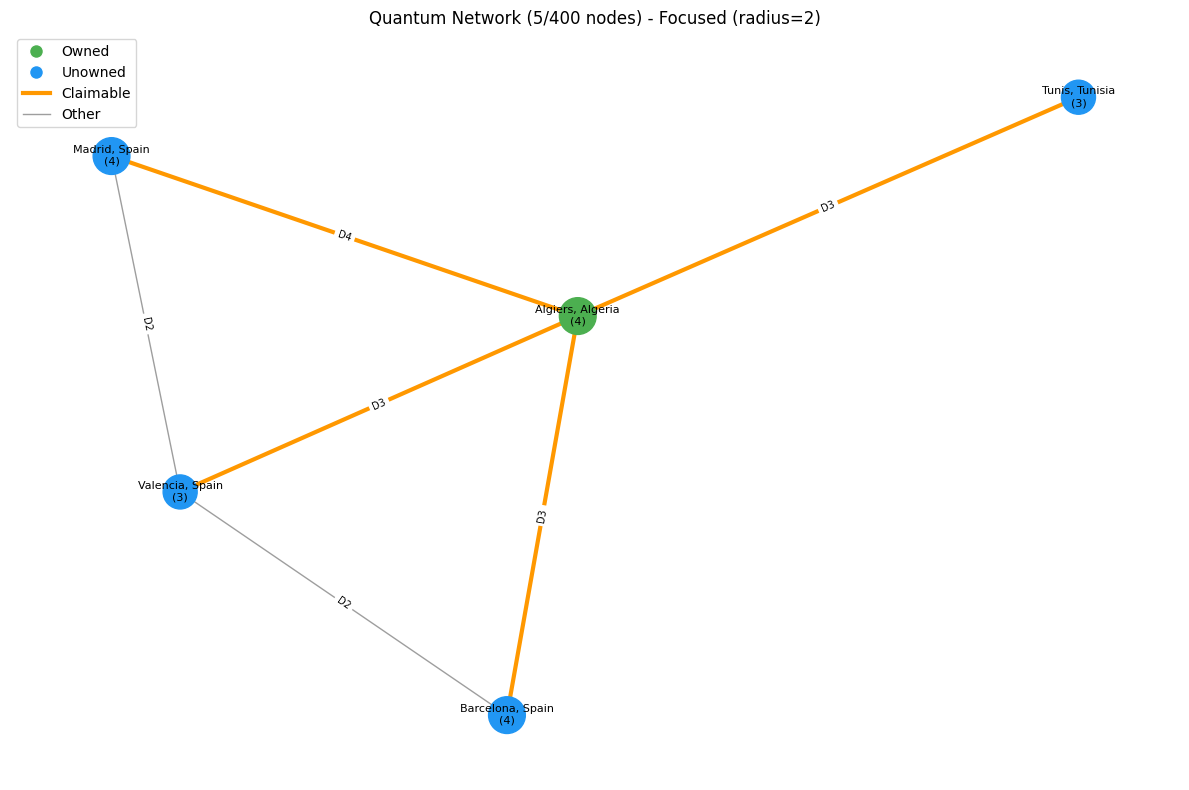

In [28]:
# Visualize the network (focused around your nodes)
viz = GraphTool(client.get_cached_graph())
owned = set(client.get_status().get('owned_nodes', []))
viz.render(owned)

## Step 4: Design a Distillation Circuit

For N Bell pairs, qubits are paired outside-in:
- Pair 0: qubits {0, 2N-1}
- Pair 1: qubits {1, 2N-2}
- ...
- Final pair: qubits {N-1, N}

Design a circuit that improves fidelity through LOCC operations.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from math import pi
# Import Parameter class
from qiskit.circuit import Parameter
from qiskit.circuit.classical import expr

In [30]:
def create_distillation_circuit():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    # TODO: Add your distillation operations here
    # Qubit layout for N=2:
    qc.cx(1,0)
    #qc.h(0)
    qc.cx(2,3)
    #qc.h(3)
    qc.measure(0,0)
    qc.measure(3,1)
    #   q0, q3: Ancilla pair (to be measured)
    #   q1, q2: Data pair (output)
    # Apply cbit 0 if both measurements were equal.
    
    return qc

dcircuit = create_distillation_circuit()
print(dcircuit.draw(output='text'))


     ┌───┐┌─┐   
q_0: ┤ X ├┤M├───
     └─┬─┘└╥┘   
q_1: ──■───╫────
           ║    
q_2: ──■───╫────
     ┌─┴─┐ ║ ┌─┐
q_3: ┤ X ├─╫─┤M├
     └───┘ ║ └╥┘
c: 3/══════╩══╩═
           0  1 


In [39]:
def zphase():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    # TODO: Add your distillation operations here
    # Qubit layout for N=2:
    qc.h(range(4))
    qc.cx(1,0)
    qc.cx(2,3)
    qc.h(1)
    qc.h(2)
    qc.measure(0,0)
    qc.measure(3,1)
    #   q0, q3: Ancilla pair (to be measured)
    #   q1, q2: Data pair (output)  

    # Apply cbit 0 if both measurements were equal.
    with qc.if_test(expr.equal(qc.clbits[0], qc.clbits[1])) as else_:
        qc.store(qc.clbits[2], True) 
    # 
    with else_:
        qc.store(qc.clbits[2], False) 
    return qc

zcircuit = zphase()
print(zcircuit.draw(output='text'))

     ┌───┐┌───┐     ┌─┐ 
q_0: ┤ H ├┤ X ├─────┤M├─
     ├───┤└─┬─┘┌───┐└╥┘ 
q_1: ┤ H ├──■──┤ H ├─╫──
     ├───┤     ├───┤ ║  
q_2: ┤ H ├──■──┤ H ├─╫──
     ├───┤┌─┴─┐└┬─┬┘ ║  
q_3: ┤ H ├┤ X ├─┤M├──╫──
     └───┘└───┘ └╥┘  ║  
c: 3/════════════╩═══╩══
                 1   0  


## Step 5: Claim an Edge

In [32]:
# Find claimable edges
claimable = client.get_claimable_edges()
claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))

print(f"Claimable edges ({len(claimable)}):")
for edge in claimable_sorted[:5]:
    print(f"  {edge['edge_id']} - threshold: {edge['base_threshold']:.3f}, difficulty: {edge['difficulty_rating']}")

Claimable edges (4):
  ['Algiers, Algeria', 'Valencia, Spain'] - threshold: 0.900, difficulty: 3
  ['Algiers, Algeria', 'Tunis, Tunisia'] - threshold: 0.900, difficulty: 3
  ['Algiers, Algeria', 'Barcelona, Spain'] - threshold: 0.900, difficulty: 3
  ['Algiers, Algeria', 'Madrid, Spain'] - threshold: 0.920, difficulty: 4


In [42]:
# Claim an edge
if claimable:
    target = claimable_sorted[0]  # Easiest edge
    edge_id = tuple(target['edge_id'])
    
    circuit = zcircuit
    num_bell_pairs = 2
    flag_bit = 2  # Classical bit for post-selection (keep when flag=0)
    
    print(f"Claiming {edge_id} (threshold: {target['base_threshold']:.3f})...")
    
    result = client.claim_edge(edge_id, circuit, flag_bit, num_bell_pairs)
    
    if result.get("ok"):
        data = result["data"]
        print(f"Success: {data.get('success')}")
        print(f"Fidelity: {data.get('fidelity', 0):.4f} (threshold: {data.get('threshold', 0):.4f})")
        print(f"Success probability: {data.get('success_probability', 0):.4f}")
    else:
        print(f"Error: {result.get('error', {}).get('message')}")

Claiming ('Algiers, Algeria', 'Valencia, Spain') (threshold: 0.900)...


HTTPError: 400 Client Error: Bad Request for url: https://demo-entanglement-distillation-qfhvrahfcq-uc.a.run.app/v1/claim_edge

## Step 6: Check Progress

In [ ]:
client.print_status()

Player: 453 (Shane)
Score: 0 | Budget: 75 bell pairs
Active: Yes
Starting node: Algiers, Algeria
Owned: 1 nodes, 0 edges
Claimable edges: 4
  - ['Algiers, Algeria', 'Valencia, Spain']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Tunis, Tunisia']: threshold=0.90, difficulty=3
  - ['Algiers, Algeria', 'Barcelona, Spain']: threshold=0.90, difficulty=3
  ... and 1 more


In [ ]:
# View leaderboard
leaderboard = client.get_leaderboard()["leaderboard"]
print("Leaderboard:")
for i, p in enumerate(leaderboard[:10]):
    print(f"{i+1}. {p.get('player_id', 'Unknown'):20} Score: {p.get('score', 0)}")

Leaderboard:
1. test_claude_1523b    Score: 277
2. ahkatlio_76f0869e    Score: 273
3. xstm                 Score: 215
4. Player12345          Score: 199
5. EnriqueAnguianoVara_b0d41a99 Score: 163
6. jeb_cui              Score: 138
7. TheSquatFather       Score: 121
8. lj123                Score: 116
9. ds08152_             Score: 114
10. GiselleRocio_remote1 Score: 114


## Tips

- **Failed attempts are free** - only successful claims cost bell pairs
- **More bell pairs** can improve fidelity but cost more budget
- **Vertex rewards** are competitive - top players by claim strength earn rewards
- **Budget management** is key - if budget reaches 0, you're eliminated

Good luck!

In [ ]:
# Restart game (uncomment to use)
# result = client.restart()
# print(result)

In [ ]:
from client import GameClient
from qiskit import QuantumCircuit
import json
from pathlib import Path

SESSION_FILE = Path("session.json")
with open(SESSION_FILE) as f:
    data = json.load(f)
client = GameClient(api_token=data.get("api_token"))
client.player_id = data.get("player_id")

def get_circuit(n_pairs):
    qc = QuantumCircuit(2*n_pairs, 2*(n_pairs-1)+1)
    
    for i in range(n_pairs-1):
        qc.cx(n_pairs-1, i)
        qc.cx(n_pairs, 2*n_pairs-1-i)
    
    for i in range(n_pairs-1):
        qc.measure(i, i)
        qc.measure(2*n_pairs-1-i, n_pairs-1+i)
    
    for i in range(n_pairs-1):
        with qc.if_test((qc.clbits[i], 1)):
            qc.x(n_pairs-1)
        with qc.if_test((qc.clbits[n_pairs-1+i], 1)):
            qc.x(n_pairs)
    
    qc.reset(1)
    for i in range(2*(n_pairs-1)):
        with qc.if_test((qc.clbits[i], 1)):
            qc.x(1)
    qc.measure(1, 2*(n_pairs-1))
    
    return qc, 2*(n_pairs-1)

while client.get_status()['budget'] >= 2:
    claimable = client.get_claimable_edges()
    if not claimable:
        break
    
    claimable_sorted = sorted(claimable, key=lambda e: (e['base_threshold'], e['difficulty_rating']))
    
    for edge_data in claimable_sorted:
        target = tuple(edge_data['edge_id'])
        thresh = edge_data['base_threshold']
        
        n_pairs = 2 if thresh <= 0.90 else (3 if thresh <= 0.92 else 4)
        
        if client.get_status()['budget'] < n_pairs:
            continue
        
        circuit, flag_bit = get_circuit(n_pairs)
        
        try:
            result = client.claim_edge(target, circuit, flag_bit, n_pairs)
            if result.get("ok") and result["data"].get('success'):
                print(f"✓ Claimed: {target[0][:20]}")
                print(f"   Score: {client.get_status()['score']}")
                break
        except:
            pass

client.print_status()